# Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms

In this document, we are replicating the work by S.Sim,P.D.Johnson and A.Aspuru-Guzik *Adv.Quantum.Technol.* **2** 1900070 (2019): https://arxiv.org/abs/1905.10876

Consider a parameterized quantum circuit $U(\mathbf{x})$, and define the quantity
$$f(\mathbf{x},\mathbf{y}) = |\langle 0 | U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}$$
This quantity is the fidelity of the two states
$$\begin{align*}
|\psi_{\mathbf{x}}\rangle = U(\mathbf{x})|0\rangle~~&\text{and}~~|\psi_{\mathbf{y}}\rangle = U(\mathbf{y})|0\rangle:\\
|\langle \psi_{\mathbf{y}}|\psi_{\mathbf{x}}\rangle|^{2} &= |\langle 0 |U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}.
\end{align*}$$

Suppose we generate a bunch of random realizations of $\mathbf{x},\mathbf{y}$. This gives us a set of random realizations of $f$; let's call that set $F = \{f_{1}, f_{2}, \cdots \}$.

To calculate the expressibility, we need to do 2 things:
* Generate a _histogram_ of the elements of $F$. The output of this histogram is a set of bins $B = \{(l_1, u_1), (l_2, u_2), \cdots \}$ where $l_{j}$ ($u_j$) denotes the lower (upper) limit of bin $j$. It also produces an empirical probability distribution function $\mathrm{Pr}_{\text{emp}}(j)$, which is simply the probability that a given value of $f$ falls in a bin $j$.
* Given the bins of the histogram, we need to compute the probability that a given fidelity value would fall into bin $j$ if the circuit generating that fidelity is drawn from a Haar-random distribution. If the circuit acts on $n$ qubits, the probability of a given fidelity value $f$ is:
$$ \mathrm{Pr}_{\text{Haar}}(f) = (N -1)*(1-f)^{N-2}, \,\,N=2^{n}.$$
To calculate the probability over a bin of the histogram, we do an integral:
$$\mathrm{Pr}_{\text{Haar}}(j) = \int_{l_{j}}^{u_{j}}  \mathrm{Pr}_{\text{Haar}}(f) ~df =  (1-l_{j})^{N-1}  - (1-u_{j})^{N-1}$$
The expressibility is then estimated as the KL divergence between the empirically-observed probability distribution (i.e., the histogram) and the probability distribution that would result under a Haar-random unitary.
$$\text{Expr} = \mathrm{KL}(\mathrm{Pr}_{\text{emp}}|| \mathrm{Pr}_{\text{Haar}}) = \sum_{j} \mathrm{Pr}_{\text{emp}}(j)\log\left(\frac{\mathrm{Pr}_{\text{emp}}(j)}{\mathrm{Pr}_{\text{Haar}}(j)}\right)$$

## Imports

In [1]:
import os
#os.environ["PL_DISABLE_MPL"] = "True"  # Disable matplotlib in PennyLane

import qiskit
from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister, Gate, Measure, ParameterVector
from qiskit import transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
#import qutip

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeTorino

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

from math import pi, sqrt

from scipy.sparse import block_diag, csr_matrix

from scipy.special import rel_entr
from scipy.stats import entropy
from scipy.special import kl_div, rel_entr
from random import seed
from random import random,choice
import random
import math

n_shots=10000
simulation_samples=5000

c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:631: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:637: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:643: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [2]:
import numpy as np

def get_negativity(rho, dim):
    """
    Calcula a negatividade de um estado quântico.
    """
    d1, d2 = dim
    rho_reshaped = rho.reshape(d1, d2, d1, d2)
    pt_rho = rho_reshaped.transpose(0, 3, 2, 1).reshape(d1*d2, d1*d2)
    eigenvalues = np.linalg.eigvals(pt_rho)
    return float(np.sum(np.abs(eigenvalues[eigenvalues < 0])))

# Estado de Bell |Φ⁺⟩ = (|00⟩ + |11⟩)/√2 (MAXIMAMENTE EMARANHADO)
def bell_state_phi_plus():
    psi = np.array([1, 0, 0, 1]) / np.sqrt(2)  # Vetor de estado
    rho = np.outer(psi, psi.conj())  # Matriz densidade
    return rho

# Estado de Bell |Φ⁻⟩ = (|00⟩ - |11⟩)/√2
def bell_state_phi_minus():
    psi = np.array([1, 0, 0, -1]) / np.sqrt(2)
    rho = np.outer(psi, psi.conj())
    return rho

# Estado de Bell |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2
def bell_state_psi_plus():
    psi = np.array([0, 1, 1, 0]) / np.sqrt(2)
    rho = np.outer(psi, psi.conj())
    return rho

# Estado de Bell |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2
def bell_state_psi_minus():
    psi = np.array([0, 1, -1, 0]) / np.sqrt(2)
    rho = np.outer(psi, psi.conj())
    return rho  

# Testando os estados de Bell
dim = (2, 2)
print("=== ESTADOS DE BELL (Negatividade = 0.5) ===")
for i, state_func in enumerate([bell_state_phi_plus, bell_state_phi_minus, 
                               bell_state_psi_plus, bell_state_psi_minus]):
    rho = state_func()
    negativity = get_negativity(rho, dim)
    print(f"Estado Bell {i+1}: Negatividade = {negativity:.6f}")

=== ESTADOS DE BELL (Negatividade = 0.5) ===
Estado Bell 1: Negatividade = 0.500000
Estado Bell 2: Negatividade = 0.500000
Estado Bell 3: Negatividade = 0.500000
Estado Bell 4: Negatividade = 0.500000


## Draws

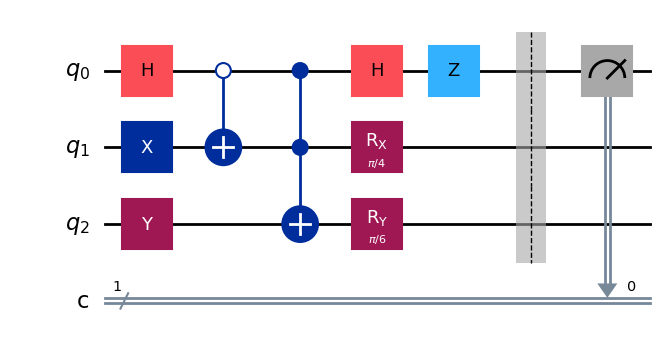

In [25]:
qc = QuantumCircuit(3,1)
qc.h(0)
qc.x(1)
qc.y(2)
qc.cx(0,1, ctrl_state=0)
qc.mcx([0,1],2)
qc.h(0)
qc.z(0)
qc.rx(pi/4,1)
qc.ry(pi/6,2)
qc.barrier()
qc.measure(0,0)
qc.draw('mpl', filename='any_quantum_circuit.svg')

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from scipy.linalg import expm

######################
# --- Funções base ---
######################

def get_weighted_sigmaQ(sigma_q_params, iqcpq=False):
    sigma_Q_base = np.array([[1, 1 - 1j], [1 + 1j, 1]], dtype=complex)
    if iqcpq:
        return np.kron(np.eye(len(sigma_q_params)//2), sigma_Q_base)
    else:
        return sigma_Q_base * sigma_q_params[0]

def expMatrix(M):
    return expm(M)

def get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcangle=False):
    X = params[:N_features]
    vw = params[N_features:]
    if iqcangle:
        sigmaE = np.diag(vw)
        dim_circuit = 2 ** (N_qubits - 1)
        dim_sigmaE = sigmaE.shape[0]
        sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
    else:
        sigmaE = np.diag(X)
    sigma_q_params = np.full(2**N_qubits_tgt, 1)
    sigmaQ = get_weighted_sigmaQ(sigma_q_params)
    return expMatrix(1j * np.kron(sigmaQ, sigmaE))


#############################
# --- Circuito IQC_Angle ---
#############################

def circuit_IQC_Angle(params, N_features, N_qubits, N_qubits_tgt, N_layers=2):
    def circuit():
        qml.Hadamard(wires=0)
        rx_params = params[:N_features]
        for _ in range(N_layers):
            for i in range(1, N_qubits):
                qml.RX(rx_params[i-1], wires=i)
            for i in range(1, N_qubits - 1):
                qml.CNOT(wires=[i, i+1])
            qml.Barrier(wires=range(N_qubits))
        U = get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcangle=True)
        qml.QubitUnitary(U, wires=range(N_qubits))
    return circuit


############################################
# --- Circuito conjugado com novos params ---
############################################

def conj_reversed_circuit(base_circuit, params_direct, params_conj):
    """
    Cria o circuito total U(params_direct) U†(params_conj)
    onde params_direct e params_conj são independentes.
    """
    def circuit():
        # parte direta
        base_circuit(params_direct)()
        # parte conjugada (adjoint) com novos parâmetros
        qml.adjoint(base_circuit(params_conj))()
    return circuit


############################################
# --- Criação do modelo completo ---
############################################

def build_IQC_angle_with_conj(params_direct, params_conj,
                              N_features, N_qubits, N_qubits_tgt, N_layers=2):
    base_circ = lambda p: circuit_IQC_Angle(p, N_features, N_qubits, N_qubits_tgt, N_layers)
    total_circ = conj_reversed_circuit(base_circ, params_direct, params_conj)
    
    dev = qml.device("default.qubit", wires=N_qubits)

    @qml.qnode(dev)
    def qnode():
        total_circ()
        # --- Adicione uma medição ---
        #return qml.state()  # ou qml.expval(qml.PauliZ(0)), ou qml.probs(...)
        return qml.sample(qml.PauliZ(wires=range(N_qubits_tgt)))
    
    return qnode


N_features = 8
N_qubits_tgt = 1
N_qubits = (N_features + N_qubits_tgt)
N_layers = 2

# parâmetros independentes
params_direct = np.random.rand(2 * N_features)
params_conj = np.random.rand(2 * N_features)

# cria o circuito completo
model = build_IQC_angle_with_conj(params_direct, params_conj,
                                  N_features, N_qubits, N_qubits_tgt, N_layers)

result = model()  # agora funciona
print(result)
print(result.shape)

### Statevector

In [ ]:
NF=13
MODEL = 'IQC_Angle'  #IQC, IQC_Angle, IQCpQ, IQCNDsE, IQC_AIL
N_qubits_tgt = 1
#Nqubits do circuito
if MODEL=='IQC_Angle':
    N_qubits = (NF+N_qubits_tgt)
else:
    N_qubits = math.ceil(np.log2(NF)+N_qubits_tgt)

NP=NF
print(NP)
if MODEL!='IQC_Angle':
    if np.log2(NF)%2!=0 and np.log2(NF)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - NF):
            NP+=1

if MODEL=='IQC_Angle':
    N_qubits = (NP+N_qubits_tgt)
else:
    N_qubits=math.ceil(np.log2(NP)+N_qubits_tgt)

print(NP)
tx = rng.random(NF)
tw = rng2.random(NF)

params=np.concatenate((tx,tw), axis=None)

"""tx = [Parameter(f'x{i}') for i in range(NP)]
tw = [Parameter(f'pw{i}') for i in range(NP)]

params=tx+tw
"""
U = get_U_operator_altered(params, N_features=NF, N_qubits=N_qubits, N_qubits_tgt=1)


qreg=QuantumRegister(N_qubits, 'q')
creg=ClassicalRegister(N_qubits_tgt)
qc = QuantumCircuit(qreg, creg)     

# Reaplica Hadamard ao final
qc.h(0)

rx_params=params[:NP]

# Armazena sequência de CNOTs
"""Aplica RXs e CNOTs, armazenando sequência, com barreira ao final."""
for l in range(2):
    for idx, qubit in enumerate(range(1, N_qubits)):
        qc.rx(rx_params[idx], qreg[qubit])
        
    for i in range(1, N_qubits - 1):
        qc.cx(qreg[i], qreg[i + 1])
    
    # Adiciona barreira
    qc.barrier()  
    

class IQC_Angle_UGate(Gate):
    def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
        super().__init__(name, num_qubits, params)
        self.N_features = N_features
        self.N_qubits_tgt = N_qubits_tgt
        
    def _define(self):
        q = QuantumRegister(self.num_qubits, 'q')
        qc = QuantumCircuit(q)
        param_values = [0]*len(self.params)  # Valores temporários
        U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcangle=True)
        #U_sparse, U_dense = get_U_sparse(param_values[:N_features], param_values[N_features:])
        #qc.unitary(U_dense, range(self.num_qubits))
        qc.unitary(U, range(self.num_qubits))
        #qc = get_U_operator_trotterized(param_values, N_qubits=self.num_qubits, N_layers=self.N_layers)

        """self.definition = qc
        param_values = [param for param in self.params]
        N_features = self.N_features
        
        U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcangle=True)
        
        # Ensure the matrix has the correct dimensions
        expected_dim = 2**self.num_qubits
        
        if U.shape != (expected_dim, expected_dim):
            print(f"Warning: Reshaping matrix from {U.shape} to ({expected_dim}, {expected_dim})")
            
            # Option 1: If matrix is too large, take the top-left block
            if U.shape[0] >= expected_dim and U.shape[1] >= expected_dim:
                U = U[:expected_dim, :expected_dim]
            # Option 2: If matrix is too small, pad with identity
            elif U.shape[0] < expected_dim or U.shape[1] < expected_dim:
                U_padded = np.eye(expected_dim, dtype=complex)
                U_padded[:U.shape[0], :U.shape[1]] = U
                U = U_padded
            else:
                raise ValueError(f"Cannot reshape matrix {U.shape} to ({expected_dim}, {expected_dim})")
        
        qc = QuantumCircuit(self.num_qubits)
        qc.unitary(U, range(self.num_qubits))"""

        self.definition = qc
    def validate_parameter(self, parameter):
        return parameter  # Aceita qualquer parâmetro


unitary_gate = IQC_Angle_UGate(f'U_{MODEL}', N_qubits, params, NP, N_qubits_tgt)
qc.append(unitary_gate, range(N_qubits))

"""sv = Statevector.from_instruction(qc)
sv.draw('latex')
sv.evolve(unitary_gate)
sv.conjugate().evolve(unitary_gate)"""
#qc.draw('mpl')

qc, U_dagger=conj_reversed_qc_angle(qc)
qc.draw('mpl')

### Funções

In [11]:
from scipy import linalg

def is_unitary(matrix, tolerance=1e-10):
    """
    Verifica se uma matriz é unitária.
    
    Uma matriz U é unitária se U†U = UU† = I, onde U† é a conjugada transposta.
    
    Parâmetros:
    -----------
    matrix : numpy.ndarray
        Matriz a ser testada
    tolerance : float, opcional
        Tolerância para erros numéricos (padrão: 1e-10)
    
    Retorna:
    --------
    bool
        True se a matriz é unitária, False caso contrário
    """
    
    # Converte para array numpy se necessário
    U = np.array(matrix, dtype=complex)
    
    # Verifica se é matriz quadrada
    if U.ndim != 2 or U.shape[0] != U.shape[1]:
        print(f"❌ Matriz não é quadrada: shape {U.shape}")
        return False
    
    n = U.shape[0]
    
    # Calcula a conjugada transposta (adjunta)
    U_dagger = U.conj().T
    
    # Verifica U†U = I
    U_dagger_U = U_dagger @ U
    identity = np.eye(n, dtype=complex)
    
    # Verifica UU† = I  
    U_U_dagger = U @ U_dagger
    
    # Testa ambas as condições
    condition1 = np.allclose(U_dagger_U, identity, atol=tolerance)
    condition2 = np.allclose(U_U_dagger, identity, atol=tolerance)
    
    if condition1 and condition2:
        print(f"Matriz {n}x{n} é unitária")
        return True
    else:
        print(f"Matriz {n}x{n} NÃO é unitária")
        if not condition1:
            print(f"   - U†U ≠ I (erro máximo: {np.max(np.abs(U_dagger_U - identity)):.2e})")
        if not condition2:
            print(f"   - UU† ≠ I (erro máximo: {np.max(np.abs(U_U_dagger - identity)):.2e})")
        return False

def is_unitary_detailed(matrix, tolerance=1e-10):
    """
    Versão detalhada que fornece mais informações sobre a unitariedade.
    """
    U = np.array(matrix, dtype=complex)
    
    if U.ndim != 2 or U.shape[0] != U.shape[1]:
        print(f"❌ Matriz não é quadrada: shape {U.shape}")
        return False
    
    n = U.shape[0]
    U_dagger = U.conj().T
    
    # Calcula produtos
    U_dagger_U = U_dagger @ U
    U_U_dagger = U @ U_dagger
    identity = np.eye(n, dtype=complex)
    
    # Métricas de erro
    error1 = np.max(np.abs(U_dagger_U - identity))
    error2 = np.max(np.abs(U_U_dagger - identity))
    
    # Determinante (deve ter módulo 1 para matrizes unitárias)
    det = np.linalg.det(U)
    det_magnitude = np.abs(det)
    
    print(f"=== Análise de Unitariedade ===")
    print(f"Dimensão: {n}x{n}")
    print(f"Erro U†U - I: {error1:.2e}")
    print(f"Erro UU† - I: {error2:.2e}")
    print(f"Determinante: {det:.6f}")
    print(f"|Determinante|: {det_magnitude:.6f}")
    
    is_unitary = error1 < tolerance and error2 < tolerance
    det_ok = np.abs(det_magnitude - 1.0) < tolerance
    
    if is_unitary and det_ok:
        print("Matriz é unitária")
    else:
        print("Matriz NÃO é unitária")
        if not is_unitary:
            print("   - Falha na condição U†U = UU† = I")
        if not det_ok:
            print(f"   - |det(U)| = {det_magnitude:.6f} ≠ 1")
    
    return is_unitary

def fix_unitary(matrix, method='nearest'):
    """
    Tenta corrigir uma matriz para se tornar unitária.
    
    Parâmetros:
    -----------
    matrix : numpy.ndarray
        Matriz a ser corrigida
    method : str
        Método de correção: 'nearest' ou 'polar'
    
    Retorna:
    --------
    numpy.ndarray
        Matriz corrigida (pode não ser perfeitamente unitária)
    """
    U = np.array(matrix, dtype=complex)
    
    if method == 'nearest':
        # Usa decomposição em valores singulares para encontrar a matriz unitária mais próxima
        u, s, vh = np.linalg.svd(U)
        return u @ vh
    
    elif method == 'polar':
        # Decomposição polar
        return linalg.polar(U)[0]
    
    else:
        raise ValueError("Método deve ser 'nearest' ou 'polar'")

def sigma_Q_to_U3():
    """
    Decompõe sigma_Q em parâmetros U3 exatos
    U3(θ, φ, λ) = [[cos(θ/2), -e^{iλ}sin(θ/2)], 
                   [e^{iφ}sin(θ/2), e^{i(φ+λ)}cos(θ/2)]]
    """
    sigma_Q = np.array([[1, 1-1j], [1+1j, -1]], dtype=complex)
    
    # Normalizar para ter determinante 1 (unitária)
    det = np.linalg.det(sigma_Q)
    sigma_Q_unit = sigma_Q / np.sqrt(det)
    
    a, b = sigma_Q_unit[0,0], sigma_Q_unit[0,1]
    c, d = sigma_Q_unit[1,0], sigma_Q_unit[1,1]
    
    # Resolver para parâmetros U3
    theta = 2 * np.arccos(np.abs(a))
    phi = np.angle(c) - np.angle(a)
    lam = np.angle(b) - np.angle(a) + np.pi  # +π para o sinal negativo
    
    print(f"Parâmetros U3 para sigma_Q: θ={theta:.4f}, φ={phi:.4f}, λ={lam:.4f}")
    return theta, phi, lam

def sigma_E_diagonal_to_U3(sigmaE):
    """
    Converte elemento diagonal de sigma_E em U3
    Para matriz diagonal: U3(0, φ, 0) = [[1, 0], [0, e^{iφ}]]
    """
    phi = 2 * np.angle(sigmaE)  # Fator 2 para U3
    
    return 0, phi, 0  # U3(0, φ, 0)

def decompose_U_full(params, N_features, theta_scale=np.sqrt(3)):
    x_values = params[:N_features]
    w_values = params[N_features:]
    """
    Decomposição completa de:
    U = I ⊗ cos(√3 σ_E) + (i/√3) σ_Q ⊗ sin(√3 σ_E)
    
    Usando apenas: CX, H, U3
    """
    n_qubits_E = len(w_values)
    total_qubits = 1 + n_qubits_E
    
    qc = QuantumCircuit(total_qubits)
    
    # Obter parâmetros U3 para sigma_Q
    theta_Q, phi_Q, lam_Q = sigma_Q_to_U3()
    
    # Ângulo do termo sin/cos
    alpha = theta_scale  # √3
    
    # IMPLEMENTAÇÃO:
    # U ≈ [I ⊗ RZ(2α)] + [sigma_Q ⊗ RX(2α/√3)] com correções
    
    # --- TERMO 1: I ⊗ cos(α σ_E) ---
    # cos(α σ_E) ≈ produto de RZ nos qubits E
    for i, (w, x) in enumerate(zip(w_values, x_values)):
        target_qubit = i + 1
        _, phi_E, _ = sigma_E_diagonal_to_U3(sigmaE[i])
        qc.u(0, alpha * phi_E, 0, target_qubit)  # RZ(α φ_E)
    
    qc.barrier()
    
    # --- TERMO 2: (i/√3) σ_Q ⊗ sin(α σ_E) ---
    # sin(α σ_E) ≈ produto de RX nos qubits E
    # Precisamos de operação controlada: sigma_Q no qubit 0 controla sin() nos qubits E
    
    # Preparar superposição para controle
    qc.h(0)
    
    # Para cada qubit E, aplicar RX controlada
    beta = 2 * np.arcsin(1/np.sqrt(3))  # Fator i/√3
    for i, (w, x) in enumerate(zip(w_values, x_values)):
        target_qubit = i + 1
        _, phi_E, _ = sigma_E_diagonal_to_U3(sigmaE[i])
        
        # RX(α φ_E) controlada = H RZ(α φ_E) H
        qc.cx(0, target_qubit)
        qc.u(0, alpha * phi_E + beta, 0, target_qubit)  # RZ controlada
        qc.cx(0, target_qubit)
    
    # Remover superposição
    qc.h(0)
    
    qc.barrier()
    
    # --- APLICAR sigma_Q NO QUBIT 0 ---
    qc.u(theta_Q, phi_Q, lam_Q, 0)
    
    # --- CORREÇÃO DE FASE PARA i ---
    qc.u(0, np.pi/2, 0, 0)  # RZ(π/2) para fator i
    
    return qc

def get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcail=False,iqcndse=False, iqcangle=False):
    X = params[:N_features]
    vw = params[N_features:]
    #Montando os sigmas
    if iqcail==True:
        N_qubits_tgt=1
        X_new=np.array(X)
        w=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(vw,0)
                X_new=np.append(X_new,0)
        
        #sigmaE=np.diag(w)
        sigmaE=w

    elif iqcndse==True:
        atx=list(X)
        atw=list(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                atw=np.append(atw,0)
                atx=np.append(atx,0)
        X_new=np.array(atx)
        w=np.array(atw)
        # Ensure sigmaE is hermitian
        sigmaE = X_new.T @ w + (X_new.T @ w).T
    
    elif iqcangle==True:
        X_new=np.array(X)
        # Verifica se precisa ajustar sigmaE
        sigmaE = vw
        # Calcula o operador unitário U
        dim_circuit = 2 ** (N_qubits-1)
        dim_sigmaE = len(sigmaE)
        #sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
        sigmaE = np.kron(np.ones(dim_circuit // dim_sigmaE), sigmaE)
        if np.log2(len(sigmaE))%2!=0 and np.log2(len(sigmaE))!=1: # Padding sigmaE
            for k in range(2**(N_qubits-N_qubits_tgt) - len(sigmaE)):
                sigmaE=np.append(sigmaE,0)

        sigmaE=np.diag(sigmaE)
    
    else:
        w = np.array(vw)
        X_new=np.array(X)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(w,0)
                X_new=np.append(X_new,0)
                #sigmaE=np.append(sigmaE,0)
        sigmaE=np.diag(X_new)*w.T
        
    
    if N_qubits_tgt==1:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=False)

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    #U_exp = np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    """if iqcndse==False and iqcangle==False:
        sigmaQ = np.asarray(sigmaQ, dtype=np.complex128)
        sigmaE = np.asarray(sigmaE, dtype=np.complex128)

        alpha = np.trace(sigmaQ @ sigmaQ) / sigmaQ.shape[0]

        if not np.allclose(sigmaQ @ sigmaQ, alpha * np.eye(sigmaQ.shape[0])):
            raise ValueError("sigmaQ^2 != α I — forma fechada inválida")
    
        sqrt_alpha = np.sqrt(alpha)
        cos_E = np.diag(np.cos(sqrt_alpha * sigmaE))
        sin_E = np.diag(np.sin(sqrt_alpha * sigmaE))

        U = (
            np.kron(np.eye(sigmaQ.shape[0]), cos_E)
            + (1j / sqrt_alpha) * np.kron(sigmaQ, sin_E)
        ) # Válido sempre que sigmaE for diagonal
    else:"""
    H = 1j*np.kron(sigmaQ,sigmaE)
    H = np.asarray(H, dtype=np.complex128)
    U = expMatrix(H)
    return U

"""def conj_reversed_qc(qc):
    '''Cria circuito reverso com parâmetros conjugados.'''
    reversed_qc = QuantumCircuit(qc.num_qubits)
    
    for instruction in reversed(qc.data):
        gate = instruction.operation
        
        if isinstance(gate, Gate):
            # Se for um gate personalizado IQC_UGate
            if hasattr(gate, '__class__') and gate.__class__.__name__ == 'IQC_UGate':
                # Para IQC_UGate, precisamos manter todos os atributos
                gate_class = type(gate)
                # Extrai todos os atributos necessários
                num_qubits = gate.num_qubits
                name = gate.name
                params = list(gate.params)
                N_features = getattr(gate, 'N_features', None)
                N_qubits_tgt = getattr(gate, 'N_qubits_tgt', None)
                
                # Cria novos parâmetros conjugados se necessário
                new_params = []
                for param in params:
                    if isinstance(param, Parameter):
                        new_params.append(Parameter(f'conj_{param.name}'))
                    else:
                        new_params.append(param)
                
                # Recria o gate com todos os atributos necessários
                if N_features is not None and N_qubits_tgt is not None:
                    new_gate = gate_class(
                        name=name,
                        num_qubits=num_qubits,
                        params=new_params,
                        N_features=N_features,
                        N_qubits_tgt=N_qubits_tgt
                    )
                else:
                    new_gate = gate_class(name=name, num_qubits=num_qubits, params=new_params)
                    
            # Para outros gates com parâmetros
            elif gate.params:
                gate_class = type(gate)
                num_qubits = gate.num_qubits
                
                # Cria novos parâmetros conjugados se necessário
                new_params = []
                for param in gate.params:
                    if isinstance(param, Parameter):
                        new_params.append(Parameter(f'conj_{param.name}'))
                    elif isinstance(param, (float, int, np.float64, np.int64)):
                        new_params.append(param)
                    elif hasattr(param, '__conjugate__'):
                        # Conjuga números complexos
                        new_params.append(param.conjugate())
                    else:
                        new_params.append(param)
                
                # Tenta criar o gate de diferentes formas
                try:
                    # Primeiro tenta com os parâmetros nomeados
                    new_gate = gate_class(
                        name=gate.name if hasattr(gate, 'name') else gate_class.__name__,
                        num_qubits=num_qubits,
                        params=new_params
                    )
                except (TypeError, AttributeError):
                    try:
                        # Tenta com parâmetros posicionais
                        new_gate = gate_class(*new_params)
                    except (TypeError, AttributeError):
                        # Se nada funcionar, usa o gate original
                        new_gate = gate
            else:
                new_gate = gate
            
            # Adiciona o gate ao circuito reverso
            reversed_qc.append(
                new_gate,
                instruction.qubits,
                instruction.clbits if instruction.clbits else []
            )
        else:
            # Para operações não-gate
            reversed_qc.append(instruction.operation, instruction.qubits, instruction.clbits)
    
    return reversed_qc
"""
def circuitm(model: str, N_features, N_qubits, N_qubits_tgt, params, N_layers=None, print_circ=False):
    if model == 'IQC':
        qc = QuantumCircuit(N_qubits, N_qubits_tgt)
        qc.h(range(N_qubits))
        
        class IQC_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQC_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))

    if model == 'IQCpQ':
        qc = QuantumCircuit(N_qubits, N_qubits_tgt)
        qc.h(range(N_qubits))
        
        class IQCpQ_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQCpQ_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))
    
    if model == 'IQCNDsE':
        qc = QuantumCircuit(N_qubits, N_qubits_tgt)
        qc.h(range(N_qubits))
        
        class IQCNDsE_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcndse=True)
                print(is_unitary(U))
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQCNDsE_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))

    if model == 'IQC_AIL':
        qc = QuantumCircuit(N_qubits,N_qubits_tgt)
        init_gate = ParamInitializeGate(N_qubits-1, params[:N_features], N_features=N_features)
        qc.append(init_gate, range(1,N_qubits))
        qc.h(0)
        
        class IQC_AIL_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcail=True)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQC_AIL_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))
    
    if model == 'IQC_Angle':
        qreg=QuantumRegister(N_qubits, 'q')
        creg=ClassicalRegister(N_qubits_tgt)
        qc = QuantumCircuit(qreg, creg)     

        # Reaplica Hadamard ao final
        qc.h(0)
        
        rx_params=params[:N_features]

        # Armazena sequência de CNOTs
        """Aplica RXs e CNOTs, armazenando sequência, com barreira ao final."""
        for l in range(N_layers):
            for idx, qubit in enumerate(range(1, N_qubits)):
                qc.rx(rx_params[idx], qreg[qubit])
                
            for i in range(1, N_qubits - 1):
                qc.cx(qreg[i], qreg[i + 1])
            
            # Adiciona barreira
            qc.barrier()  
          
    
        class IQC_Angle_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcangle=True)
                #U_sparse, U_dense = get_U_sparse(param_values[:N_features], param_values[N_features:])
                #qc.unitary(U_dense, range(self.num_qubits))
                qc.unitary(U, range(self.num_qubits))
                #qc = get_U_operator_trotterized(param_values, N_qubits=self.num_qubits, N_layers=self.N_layers)

                """self.definition = qc
                param_values = [param for param in self.params]
                N_features = self.N_features
                
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcangle=True)
                
                # Ensure the matrix has the correct dimensions
                expected_dim = 2**self.num_qubits
                
                if U.shape != (expected_dim, expected_dim):
                    print(f"Warning: Reshaping matrix from {U.shape} to ({expected_dim}, {expected_dim})")
                    
                    # Option 1: If matrix is too large, take the top-left block
                    if U.shape[0] >= expected_dim and U.shape[1] >= expected_dim:
                        U = U[:expected_dim, :expected_dim]
                    # Option 2: If matrix is too small, pad with identity
                    elif U.shape[0] < expected_dim or U.shape[1] < expected_dim:
                        U_padded = np.eye(expected_dim, dtype=complex)
                        U_padded[:U.shape[0], :U.shape[1]] = U
                        U = U_padded
                    else:
                        raise ValueError(f"Cannot reshape matrix {U.shape} to ({expected_dim}, {expected_dim})")
                
                qc = QuantumCircuit(self.num_qubits)
                qc.unitary(U, range(self.num_qubits))"""

                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro

    
        unitary_gate = IQC_Angle_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))

    if print_circ:
        display(qc.draw('mpl'))

    if model=='IQC_AIL': 
        qc,_ = conj_reversed_qc_ail(qc)
        return qc
    elif model=='IQC_Angle':
        qc,_ = conj_reversed_qc_angle(qc)
        return qc
    else: 
        qc,_ = conj_reversed_qc(qc)
        return qc


In [ ]:
NF=4
MODEL = 'IQCNDsE' #IQC, IQC_Angle, IQCpQ, IQCNDsE, IQC_AIL
N_qubits_tgt= 1
#Nqubits do circuito
if MODEL=='IQC_Angle':
    N_qubits = (NF+N_qubits_tgt)
else:
    N_qubits = math.ceil(np.log2(NF)+N_qubits_tgt)

NP=NF
print(NP)
if MODEL!='IQC_Angle':
    if np.log2(NF)%2!=0 and np.log2(NF)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - NF):
            NP+=1

if MODEL=='IQC_Angle':
    N_qubits = (NP+N_qubits_tgt)
else:
    N_qubits=math.ceil(np.log2(NP)+N_qubits_tgt)

print(NP)
tx = rng.random(NP)
tw = rng2.random(NP)

params=np.concatenate((tx,tw), axis=None)
print(params.shape)
qc = QuantumCircuit(N_qubits, N_qubits_tgt)
qc.h(range(N_qubits))

"""tx = [Parameter(f'x{i}') for i in range(NP)]
tw = [Parameter(f'pw{i}') for i in range(NP)]

params=tx+tw

param_binding = {p : rng.random() for p in qc.parameters}
        
qc.assign_parameters(param_binding, inplace=True)

"""
U = get_U_operator_altered(params, N_features=NP, N_qubits=N_qubits, N_qubits_tgt=1, iqcndse=True)

# Criar circuito
qc = circuitm(MODEL, N_features=NP, N_qubits=N_qubits, N_qubits_tgt=1, params=params, N_layers=2, print_circ=True)

qc = qc.decompose(reps=0)

display(qc.draw('mpl'))

"""
qc = decompose_U_full(params, NF, theta_scale=np.sqrt(3))

print(f"\nCircuito resultante:")
display(I'  #IQC,qc.draw('mpl'))

print(f"\nNúmero de portas:")
print(f"U3: {qc.count_ops().get('u3', 0)}")
print(f"CX: {qc.count_ops().get('cx', 0)}") conda
print(f"H: {qc.count_ops().get('h', 0)}")"""

In [ ]:
from sympy import symbols
a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z = symbols('a b c d e f g h i j k l m n o p q r s t u v w x y z')
lista_symbols=[a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z]
m1 = np.random.choice (lista_symbols, 2)
m2 = np.random.choice (lista_symbols, 2)
print(m1*m2)

[y**2 j*n]


In [ ]:
NF=13
MODEL = 'IQC'  #IQC, IQC_Angle, IQCpQ, IQCNDsE, IQC_AIL
N_qubits_tgt = 1
#Nqubits do circuito
if MODEL=='IQC_Angle':
    N_qubits = (NF+N_qubits_tgt)
else:
    N_qubits = math.ceil(np.log2(NF)+N_qubits_tgt)

NP=NF
print(NP)
if MODEL!='IQC_Angle':
    if np.log2(NF)%2!=0 and np.log2(NF)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - NF):
            NP+=1

if MODEL=='IQC_Angle':
    N_qubits = (NP+N_qubits_tgt)
else:
    N_qubits=math.ceil(np.log2(NP)+N_qubits_tgt)

print(NP)
tx = [Parameter(f'x{i}') for i in range(NP)]
tw = [Parameter(f'pw{i}') for i in range(NP)]

params=tx+tw

if MODEL=='IQC_Angle':
    qc = circuitm(MODEL,NP,N_qubits,N_qubits_tgt,params=params, N_layers=2)
else:
    qc = circuitm(MODEL,NP,N_qubits,N_qubits_tgt,params=params)

#display(qc.draw('mpl'))

param_binding = {p : rng.random() for p in qc.parameters}
        
qc.assign_parameters(param_binding, inplace=True)

#display(qc.draw('mpl'))

"""
pass_manager=generate_preset_pass_manager(backend=backend, optimization_level=3, translation_method='synthesis', basis_gates=['u', 'cx', 'h', 'cx'])
transpiled_circuit = pass_manager.run(qc)
display(transpiled_circuit.draw('mpl'))"""

backend = FakeTorino()

qc = qc.decompose(reps=1)  # Expande todas as portas compostas

#display(qc.draw('mpl'))
tqc = transpile(qc, backend=backend, basis_gates=['u3', 'x', 'h', 'z', 'cx'], optimization_level=0)

tqc.draw('mpl')



## Expressibility

In [14]:
def expressibility(MODEL,NF, print_hist=False, print_circuit=False):
    if MODEL=='IQC_Angle':
        N_qubits_tgt=1
        N_qubits=(NF+N_qubits_tgt)
    elif MODEL=='IQCpQ':
        N_qubits_tgt=2
        N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
    else:
        N_qubits_tgt=1
        N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
    
    string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito

    P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

    folder=f'NF{NF}_'+MODEL
    # Check if the diretory does exists and create it, if it doesn't
    if not os.path.exists(folder):
        os.makedirs(folder)

    tx = [Parameter(f'x{i}') for i in range(NF)]
    tw = [Parameter(f'pw{i}') for i in range(NF)]

    if np.log2(NF)%2!=0 and np.log2(NF)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - NF):
            tw.append(Parameter(f'padding_pw{k}'))
            tx.append(Parameter(f'padding_x{k}'))

    params=tx+tw

    if MODEL=='IQC_Angle':
        qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)
    else:
        qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

    fidelity=[]    
    for _ in range(simulation_samples):
        if MODEL=='IQC_Angle':
            param_binding = {p : np.pi*rng.random() for p in qc.parameters}
        else:
            param_binding = {p : rng.random() for p in qc.parameters}
        
        qc.assign_parameters(param_binding, inplace=True)
        qc = qc.decompose(reps=10)  # Expande todas as portas compostas
        tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)#, backend=FakeTorino(), basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
        
        count=run_qasm_counts(tqc, n_shots, N_qubits_tgt)
        
        
        
        if string_zero in count and '1' in count:
            ratio=count[string_zero]/n_shots
        elif string_zero in count and '1' not in count:
            ratio=count[string_zero]/n_shots
        else:
            ratio=0
        fidelity.append(ratio)

    if print_circuit:      
        display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

    weights = np.ones_like(fidelity)/float(len(fidelity))
    if print_hist:
        plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label=MODEL)
        plt.plot(bins_x, P_harr_hist, label='Harr')
        plt.legend(loc='upper right')
        plt.ylabel('Probability')
        plt.xlabel('Fidelity')
        plt.title(f'Fidelity Distribution - NF{NF} - {MODEL}')
        plt.tight_layout()
        plt.savefig(folder+f'/Expressibility_Hist_NF{NF}_{MODEL}.svg')
        plt.show()

    # example of calculating the kl divergence (relative entropy) with scipy
    P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
    kl_pq = entropy(P_I_hist, P_harr_hist)
    print('S(P || Q) = %.3f' % kl_pq)

    return kl_pq

## NF2

In [9]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=2

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:631: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:637: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:643: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


ValueError: Input matrix is not unitary.

## NF4

In [15]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=4

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

S(P || Q) = 2.411
KL Divergence for NF4 - IQC: 2.411486697577223
S(P || Q) = 1.078
KL Divergence for NF4 - IQC_Angle: 1.0776494966187868
S(P || Q) = 1.702
KL Divergence for NF4 - IQCpQ: 1.7017179686039563
Matriz 2x2 é unitária
True
Matriz 2x2 é unitária
True
S(P || Q) = 2.411
KL Divergence for NF4 - IQCNDsE: 2.411486697577223


LinAlgError: Last 2 dimensions of the array must be square

## NF13

In [5]:
MODELS_LIST=['IQC','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=13

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

TranspilerError: 'HighLevelSynthesis is unable to synthesize "U_IQC"'

## NF8

In [ ]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=8

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

## Plot

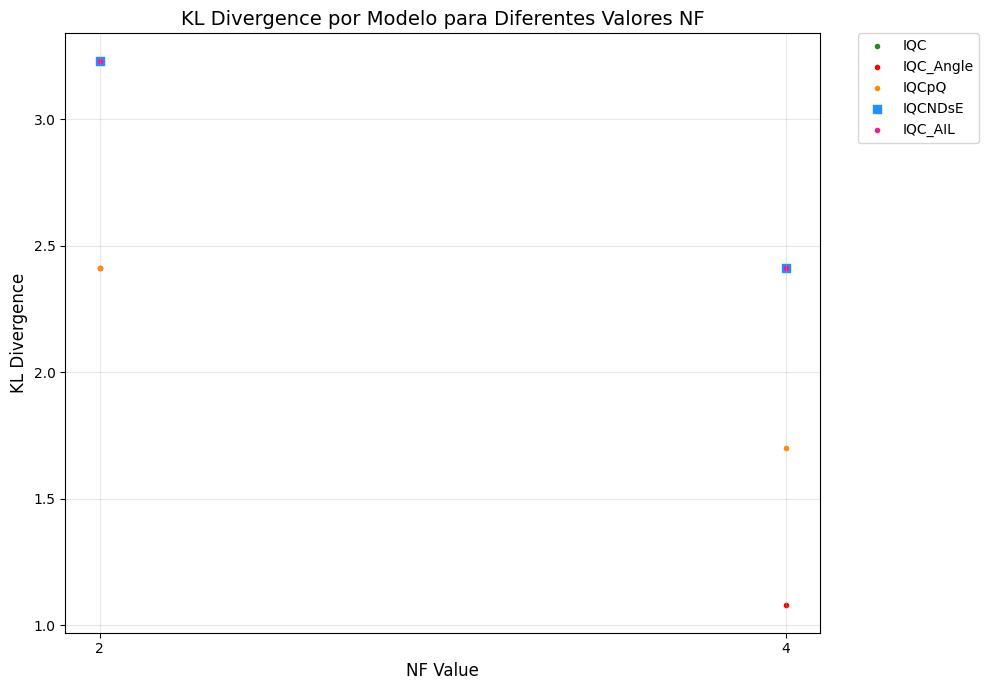


Estatísticas dos dados processados:

NF 2:
  Número de modelos: 5
  KL Divergence - Média: 2.9039
  KL Divergence - Desvio padrão: 0.4495

NF 4:
  Número de modelos: 5
  KL Divergence - Média: 2.0028
  KL Divergence - Desvio padrão: 0.6016


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_expressibilities(arquivos_csv):
    """
    Lê arquivos CSV e plota KL Divergence por modelo, com cada arquivo representado no eixo X pelo número NF
    """
    
    # Configurações do plot
    plt.figure(figsize=(10,7))
    
    # Cores diferentes para cada modelo
    cores =  ['forestgreen','red','darkorange','dodgerblue','deeppink']
    #cores = plt.cm.tab20(np.linspace(0, 5, 20))  # Paleta com 20 cores distintas
    
    # Dicionário para armazenar todos os dados
    todos_dados = {}
    
    # Processar cada arquivo
    for arquivo in arquivos_csv:
        try:
            # Extrair número NF do nome do arquivo
            nome_base = os.path.basename(arquivo)
            numero_nf = ''.join(filter(str.isdigit, nome_base.split('_')[0]))
            
            # Ler o arquivo CSV
            df = pd.read_csv(arquivo)
            
            # Verificar se as colunas necessárias existem
            if 'KL Divergence' not in df.columns or 'Models' not in df.columns:
                print(f"Aviso: Arquivo {arquivo} não possui as colunas 'KL Divergence' e 'Models'")
                continue
            
            # Armazenar dados
            todos_dados[numero_nf] = df
            
        except FileNotFoundError:
            print(f"Erro: Arquivo {arquivo} não encontrado")
            continue
        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")
            continue
    
    # Plotar dados
    modelos_plotados = set()  # Para controlar a legenda
    x_positions = []  # Para armazenar posições no eixo X
    
    for i, (nf, df) in enumerate(todos_dados.items()):
        x_pos = i + 1  # Posição no eixo X (1, 2, 3, ...)
        x_positions.append(x_pos)
        
        # Plotar cada modelo do arquivo atual
        for idx, row in df.iterrows():
            modelo = row['Models']
            kl_divergence = row['KL Divergence']
            
            # Definir marcador baseado no modelo
            if modelo == "IQCNDsE":
                marcador = 's'  # Quadrado para IQCNDsE
            else:
                marcador = '.'  # Ponto para outros modelos
            
            # Verificar se o modelo já foi plotado antes (para legenda)
            if modelo not in modelos_plotados:
                plt.scatter(x_pos, kl_divergence, 
                           color=cores[idx % len(cores)], 
                           marker=marcador,
                           label=modelo, alpha=1)
                modelos_plotados.add(modelo)
            else:
                plt.scatter(x_pos, kl_divergence, 
                           color=cores[idx % len(cores)], 
                           marker=marcador,
                           alpha=1)
    
    # Configurações do gráfico
    plt.xlabel('NF Value', fontsize=12)
    plt.ylabel('KL Divergence', fontsize=12)
    plt.title('KL Divergence por Modelo para Diferentes Valores NF', fontsize=14)
    
    # Configurar eixo X
    if x_positions:
        plt.xticks(x_positions, list(todos_dados.keys()))
    
    # Legenda
    if modelos_plotados:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return todos_dados

# Lista de arquivos - ADICIONE AQUI OS NOVOS ARQUIVOS
arquivos = [
    'NF2_models_expressibilities.csv',
    'NF4_models_expressibilities.csv'
    # Adicione novos arquivos aqui, por exemplo:
    # 'NF6_models_expressibilities.csv',
    # 'NF8_models_expressibilities.csv'
]

# Executar a função
dados_processados = plot_expressibilities(arquivos)

# Opcional: Mostrar estatísticas dos dados
print("\nEstatísticas dos dados processados:")
for nf, df in dados_processados.items():
    print(f"\nNF {nf}:")
    print(f"  Número de modelos: {len(df)}")
    print(f"  KL Divergence - Média: {df['KL Divergence'].mean():.4f}")
    print(f"  KL Divergence - Desvio padrão: {df['KL Divergence'].std():.4f}")